In [ ]:
# Cell 1: Connect Google Drive and check the Colab machine
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT = '/content/drive/MyDrive/BDA_Project'
os.makedirs(PROJECT + '/evidence', exist_ok=True)
print('Project folder ready:', PROJECT)

!echo "--- CPU cores ---" && nproc
!echo "--- Memory ---" && free -h | head -2
!echo "--- Disk ---" && df -h /content | tail -1

Mounted at /content/drive
Project folder ready: /content/drive/MyDrive/BDA_Project
--- CPU cores ---
2
--- Memory ---
               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.1Gi       8.6Gi       2.1Mi       3.3Gi        11Gi
--- Disk ---
overlay         108G   21G   88G  19% /


In [ ]:
# Cell 2: Upload the Kaggle API key (kept private)
from google.colab import files
files.upload()   # choose kaggle.json
!mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
print('Kaggle key installed')

Saving kaggle.json to kaggle.json
Kaggle key installed


In [ ]:
# Cell 3: Download 2019-Oct.csv from the REES46 dataset
!pip -q install kaggle
!mkdir -p /content/data
!kaggle datasets download -d mkechinov/ecommerce-behavior-data-from-multi-category-store -f 2019-Oct.csv -p /content/data
# Kaggle sometimes delivers a zip; unzip if so
!cd /content/data && for z in *.zip; do [ -f "$z" ] && unzip -o "$z" && rm "$z"; done; true
!echo "--- Files and sizes ---" && ls -lh /content/data
!echo "--- First 3 lines ---" && head -3 /content/data/2019-Oct.csv

Dataset URL: https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store
License(s): copyright-authors
100% 1.61G/1.61G [00:41<00:00, 41.6MB/s]

Archive:  2019-Oct.csv.zip
  inflating: 2019-Oct.csv            
--- Files and sizes ---
total 5.3G
-rw-r--r-- 1 root root 5.3G Dec  9  2019 2019-Oct.csv
--- First 3 lines ---
event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc


In [ ]:
# Cell 4: Session-based extract (keeps complete sessions across all of October)
!awk -F',' 'NR==1 || $9 ~ /[01]$/' /content/data/2019-Oct.csv > /content/data/oct_extract.csv
!echo "--- Extract size ---" && ls -lh /content/data/oct_extract.csv
!echo "--- Exact bytes ---" && stat -c %s /content/data/oct_extract.csv
!echo "--- Line count (includes header) ---" && wc -l /content/data/oct_extract.csv
!echo "--- Full file line count (includes header) ---" && wc -l /content/data/2019-Oct.csv
!echo "--- First and last event times ---" && sed -n 2p /content/data/oct_extract.csv | cut -d, -f1 && tail -1 /content/data/oct_extract.csv | cut -d, -f1

--- Extract size ---
-rw-r--r-- 1 root root 676M Sep 17 00:38 /content/data/oct_extract.csv
--- Exact bytes ---
707882575
--- Line count (includes header) ---
5302033 /content/data/oct_extract.csv
--- Full file line count (includes header) ---
42448765 /content/data/2019-Oct.csv
--- First and last event times ---
2019-10-01 00:00:10 UTC
2019-10-31 23:59:58 UTC


In [ ]:
# Cell 5: Profile the extract (event types, missing values, users, sessions)
import pandas as pd
df = pd.read_csv('/content/data/oct_extract.csv',
                 dtype={'event_type':'category','category_code':'string','brand':'string',
                        'user_session':'string'})
print('Rows:', len(df))
print('\n--- Event types ---'); print(df['event_type'].value_counts())
print('\n--- Missing values (count) ---'); print(df.isna().sum())
print('\n--- Missing values (%) ---'); print((df.isna().mean()*100).round(2))
print('\nUnique users:', df['user_id'].nunique())
print('Unique sessions:', df['user_session'].nunique())
print('Unique products:', df['product_id'].nunique())
print('\n--- Price ---'); print(df['price'].describe().round(2))

Rows: 5302032

--- Event types ---
event_type
view        5094273
cart         115883
purchase      91876
Name: count, dtype: int64

--- Missing values (count) ---
event_time             0
event_type             0
product_id             0
category_id            0
category_code    1692171
brand             765544
price                  0
user_id                0
user_session           0
dtype: int64

--- Missing values (%) ---
event_time        0.00
event_type        0.00
product_id        0.00
category_id       0.00
category_code    31.92
brand            14.44
price             0.00
user_id           0.00
user_session      0.00
dtype: float64

Unique users: 823761
Unique sessions: 1155744
Unique products: 125017

--- Price ---
count    5302032.00
mean         289.97
std          358.13
min            0.00
25%           65.87
50%          162.17
75%          358.57
max         2574.07
Name: price, dtype: float64


In [ ]:
# Cell 6: Back up the extract to Google Drive (about 676 MB)
!cp /content/data/oct_extract.csv /content/drive/MyDrive/BDA_Project/
!ls -lh /content/drive/MyDrive/BDA_Project/oct_extract.csv

-rw------- 1 root root 676M Sep 17 00:42 /content/drive/MyDrive/BDA_Project/oct_extract.csv


In [ ]:
# Cell 7: Get dataset metadata (for the reference year)
!kaggle datasets list -s "ecommerce behavior data from multi category store" --csv

ref,title,size,lastUpdated,downloadCount,voteCount,usabilityRating
mkechinov/ecommerce-behavior-data-from-multi-category-store,eCommerce behavior data from multi category store,4606720907,2019-12-09 20:43:39.273000,84587,900,1
dschettler8845/recsys-2020-ecommerce-dataset,Recommender System - E-Commerce Dataset - 2020,659903439,2021-01-01 17:48:41.997000,4194,45,0.9375
yashtyagi1712/ecommercebehaviordatafrommulticategorystore,ecommerce-behavior-data-from-multi-category-store,4606720907,2023-01-07 20:34:41.740000,151,1,0.23529412
andydovn/ecommerce-behavior-data-from-multi-category-store,eCommerce behavior data from multi category store,1732595746,2025-07-30 00:15:04.783000,110,0,0.4117647
egirizkiyansyah44/ecommerce-behavior-data-from-multi-category-store,eCommerce behavior data from multi category store,87521311,2026-04-05 14:43:28.917000,30,0,0.23529412
adarsh11/ecomm-propensity-gold-clean,E-commerce Propensity - Gold Dataset,3052024774,2026-02-02 13:58:33.070000,40,1,0.9411765
autowi

In [ ]:
# Cell 8: Reconnect Drive and restore the extract to fast local disk
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p /content/data
![ -f /content/data/oct_extract.csv ] || cp /content/drive/MyDrive/BDA_Project/oct_extract.csv /content/data/
!ls -l /content/data/oct_extract.csv

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
-rw-r--r-- 1 root root 707882575 Sep 17 00:38 /content/data/oct_extract.csv


In [ ]:
# Cell 9: Install Java 11 and Apache Hadoop 3.3.6 (tarball cached in Drive)
!apt-get -qq update > /dev/null && apt-get -qq install -y openjdk-11-jdk-headless > /dev/null
CACHE = '/content/drive/MyDrive/BDA_Project/software'
!mkdir -p {CACHE}
![ -f {CACHE}/hadoop-3.3.6.tar.gz ] || wget -q --show-progress -O {CACHE}/hadoop-3.3.6.tar.gz https://archive.apache.org/dist/hadoop/common/hadoop-3.3.6/hadoop-3.3.6.tar.gz
!tar -xzf {CACHE}/hadoop-3.3.6.tar.gz -C /opt/ && ln -sfn /opt/hadoop-3.3.6 /opt/hadoop

import os
os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-11-openjdk-amd64'
os.environ['HADOOP_HOME'] = '/opt/hadoop'
os.environ['PATH'] = '/opt/hadoop/bin:/opt/hadoop/sbin:' + os.environ['PATH']

!echo "--- Java ---" && java -version
!echo "--- Hadoop ---" && hadoop version | head -4

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
/content/drive/MyDr 100%[===================>] 696.28M  4.87MB/s    in 1m 58s  
--- Java ---
[0.026s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.026s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)
--- Hadoop ---
Hadoop 3.3.6
Source code repository https://github.com/apache/hadoop.git -r 1be78238728da9266a4f88195058f08fd012bf9c
Compiled by ubuntu on 2023-06-18T08:22Z
Compiled on platform linux-x86_64


In [1]:
# Cell 10: Verify Java 11 exists and make it the default Java
!ls -d /usr/lib/jvm/*/
!apt-get -qq install -y openjdk-11-jdk-headless > /dev/null 2>&1 || echo "APT INSTALL FAILED"
!update-alternatives --set java /usr/lib/jvm/java-11-openjdk-amd64/bin/java 2>&1 | tail -1
import os
os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-11-openjdk-amd64'
os.environ['PATH'] = '/usr/lib/jvm/java-11-openjdk-amd64/bin:/opt/hadoop/bin:/opt/hadoop/sbin:' + os.environ['PATH']
!echo "--- Java now ---" && java -version 2>&1 | grep version
!echo "--- JAVA_HOME ---" && echo $JAVA_HOME && ls $JAVA_HOME/bin/java

/usr/lib/jvm/java-1.21.0-openjdk-amd64/  /usr/lib/jvm/java-21-openjdk-amd64/
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/java to provide /usr/bin/java (java) in manual mode
--- Java now ---
openjdk version "11.0.32" 2026-07-21
--- JAVA_HOME ---
/usr/lib/jvm/java-11-openjdk-amd64
/usr/lib/jvm/java-11-openjdk-amd64/bin/java


In [8]:
# Cell 11a: Diagnose and repair the Hadoop installation
!echo "--- Before ---" && ls -la /opt | grep -i hadoop; ls /opt/hadoop/etc/hadoop/hadoop-env.sh 2>&1
![ -f /opt/hadoop-3.3.6/etc/hadoop/hadoop-env.sh ] || (rm -rf /opt/hadoop-3.3.6 && tar -xzf /content/drive/MyDrive/BDA_Project/software/hadoop-3.3.6.tar.gz -C /opt/)
!rm -rf /opt/hadoop && ln -s /opt/hadoop-3.3.6 /opt/hadoop
import os
os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-11-openjdk-amd64'
os.environ['HADOOP_HOME'] = '/opt/hadoop'
os.environ['PATH'] = '/usr/lib/jvm/java-11-openjdk-amd64/bin:/opt/hadoop/bin:/opt/hadoop/sbin:' + os.environ['PATH']
!echo "--- After ---" && ls -la /opt | grep -i hadoop && ls /opt/hadoop/etc/hadoop/hadoop-env.sh && hadoop version | head -1 && java -version 2>&1 | grep version

--- Before ---
lrwxrwxrwx  1 root   root     17 Sep 17 12:59 hadoop -> /opt/hadoop-3.3.6
drwxr-xr-x 10 ubuntu ubuntu 4096 Jun 18  2023 hadoop-3.3.6
/opt/hadoop/etc/hadoop/hadoop-env.sh
--- After ---
lrwxrwxrwx  1 root   root     17 Sep 17 13:13 hadoop -> /opt/hadoop-3.3.6
drwxr-xr-x 10 ubuntu ubuntu 4096 Jun 18  2023 hadoop-3.3.6
/opt/hadoop/etc/hadoop/hadoop-env.sh
Hadoop 3.3.6
openjdk version "11.0.32" 2026-07-21


In [9]:
# Cell 11: Hadoop configuration (pseudo-distributed: NN, SNN, 3 DNs, RM, NM)
import os, shutil
H='/opt/hadoop'; CONF=f'{H}/etc/hadoop'; BASE='/content/hdfs'
for d in ['namenode','secondary','dn1','dn2','dn3']:
    os.makedirs(f'{BASE}/{d}', exist_ok=True)

def xml(path, props):
    body=''.join(f'  <property><name>{k}</name><value>{v}</value></property>\n' for k,v in props.items())
    open(path,'w').write('<?xml version="1.0"?>\n<configuration>\n'+body+'</configuration>\n')

# Environment: Java 11, allow daemons to run as root in Colab, modest memory per daemon
with open(f'{CONF}/hadoop-env.sh','a') as f:
    f.write('''
export JAVA_HOME=/usr/lib/jvm/java-11-openjdk-amd64
export HDFS_NAMENODE_USER=root HDFS_DATANODE_USER=root HDFS_SECONDARYNAMENODE_USER=root
export YARN_RESOURCEMANAGER_USER=root YARN_NODEMANAGER_USER=root
export HDFS_NAMENODE_OPTS="-Xmx1g" HDFS_SECONDARYNAMENODE_OPTS="-Xmx512m" HDFS_DATANODE_OPTS="-Xmx512m"
export YARN_RESOURCEMANAGER_OPTS="-Xmx1g" YARN_NODEMANAGER_OPTS="-Xmx1g"
''')

xml(f'{CONF}/core-site.xml', {'fs.defaultFS':'hdfs://localhost:9000', 'hadoop.tmp.dir':'/content/hadoop-tmp'})
hdfs = {'dfs.replication':'3', 'dfs.blocksize':'134217728',
        'dfs.namenode.name.dir':f'file://{BASE}/namenode',
        'dfs.namenode.checkpoint.dir':f'file://{BASE}/secondary',
        'dfs.namenode.checkpoint.period':'120', 'dfs.permissions.enabled':'false'}
xml(f'{CONF}/hdfs-site.xml', hdfs)
env = f'HADOOP_MAPRED_HOME={H}'
xml(f'{CONF}/mapred-site.xml', {'mapreduce.framework.name':'yarn',
    'yarn.app.mapreduce.am.env':env, 'mapreduce.map.env':env, 'mapreduce.reduce.env':env,
    'yarn.app.mapreduce.am.resource.mb':'1024', 'yarn.app.mapreduce.am.command-opts':'-Xmx800m',
    'mapreduce.map.memory.mb':'1024', 'mapreduce.map.java.opts':'-Xmx800m',
    'mapreduce.reduce.memory.mb':'1024', 'mapreduce.reduce.java.opts':'-Xmx800m'})
xml(f'{CONF}/yarn-site.xml', {'yarn.resourcemanager.hostname':'localhost',
    'yarn.nodemanager.aux-services':'mapreduce_shuffle',
    'yarn.nodemanager.resource.memory-mb':'5120', 'yarn.nodemanager.resource.cpu-vcores':'4',
    'yarn.scheduler.minimum-allocation-mb':'512', 'yarn.scheduler.maximum-allocation-mb':'4096',
    'yarn.nodemanager.vmem-check-enabled':'false',
    'yarn.nodemanager.disk-health-checker.max-disk-utilization-per-disk-percentage':'95',
    'yarn.nodemanager.env-whitelist':'JAVA_HOME,HADOOP_COMMON_HOME,HADOOP_HDFS_HOME,HADOOP_CONF_DIR,CLASSPATH_PREPEND_DISTCACHE,HADOOP_YARN_HOME,HADOOP_HOME,PATH,LANG,TZ,HADOOP_MAPRED_HOME'})

# One config folder per DataNode: own data directory and own ports
ports = {1:(9866,9864,9867), 2:(19866,19864,19867), 3:(29866,29864,29867)}
for i,(data,http,ipc) in ports.items():
    dconf=f'{H}/conf-dn{i}'
    shutil.rmtree(dconf, ignore_errors=True); shutil.copytree(CONF, dconf)
    xml(f'{dconf}/hdfs-site.xml', {**hdfs, 'dfs.datanode.data.dir':f'file://{BASE}/dn{i}',
        'dfs.datanode.address':f'0.0.0.0:{data}', 'dfs.datanode.http.address':f'0.0.0.0:{http}',
        'dfs.datanode.ipc.address':f'0.0.0.0:{ipc}'})

# Keep a copy of the configuration in Drive for the appendix
EV='/content/drive/MyDrive/BDA_Project/evidence/config'
os.makedirs(EV, exist_ok=True)
for f in ['core-site.xml','hdfs-site.xml','mapred-site.xml','yarn-site.xml']:
    shutil.copy(f'{CONF}/{f}', EV)
shutil.copy(f'{H}/conf-dn2/hdfs-site.xml', f'{EV}/hdfs-site-dn2.xml')
print('Configuration written and saved to Drive')
!hdfs getconf -confKey dfs.blocksize && hdfs getconf -confKey dfs.replication

Configuration written and saved to Drive
134217728
3


In [10]:
# Cell 12: Format HDFS (creates the initial FSImage)
!hdfs namenode -format -force -nonInteractive 2>&1 | grep -E "successfully formatted|Saving image|ERROR|Exception"
!ls /content/hdfs/namenode/current/

2026-09-17 13:14:01,928 INFO common.Storage: Storage directory /content/hdfs/namenode has been successfully formatted.
2026-09-17 13:14:02,002 INFO namenode.FSImageFormatProtobuf: Saving image file /content/hdfs/namenode/current/fsimage.ckpt_0000000000000000000 using no compression
fsimage_0000000000000000000	 seen_txid
fsimage_0000000000000000000.md5  VERSION


In [7]:
# Cell 11b: Reinstall Hadoop 3.3.6 via local disk, then back up to Drive
!echo "--- Drive software folder ---" && ls -la /content/drive/MyDrive/BDA_Project/software/ 2>&1
!echo "--- /opt contents ---" && ls /opt
!rm -f /content/hadoop-3.3.6.tar.gz
!wget -q --show-progress -O /content/hadoop-3.3.6.tar.gz https://archive.apache.org/dist/hadoop/common/hadoop-3.3.6/hadoop-3.3.6.tar.gz
!rm -rf /opt/hadoop /opt/hadoop-3.3.6 && tar -xzf /content/hadoop-3.3.6.tar.gz -C /opt/ && ln -s /opt/hadoop-3.3.6 /opt/hadoop
import os
os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-11-openjdk-amd64'
os.environ['HADOOP_HOME'] = '/opt/hadoop'
os.environ['PATH'] = '/usr/lib/jvm/java-11-openjdk-amd64/bin:/opt/hadoop/bin:/opt/hadoop/sbin:' + os.environ['PATH']
!echo "--- Check ---" && ls -l /content/hadoop-3.3.6.tar.gz && ls /opt/hadoop/etc/hadoop/hadoop-env.sh && hadoop version | head -1 && java -version 2>&1 | grep version
!mkdir -p /content/drive/MyDrive/BDA_Project/software && cp /content/hadoop-3.3.6.tar.gz /content/drive/MyDrive/BDA_Project/software/ && echo "Backup copied to Drive"

--- Drive software folder ---
ls: cannot access '/content/drive/MyDrive/BDA_Project/software/': No such file or directory
--- /opt contents ---
google	hadoop
/content/hadoop-3.3 100%[===================>] 696.28M   102KB/s    in 77m 59s 
--- Check ---
-rw-r--r-- 1 root root 730107476 Jun 25  2023 /content/hadoop-3.3.6.tar.gz
/opt/hadoop/etc/hadoop/hadoop-env.sh
Hadoop 3.3.6
openjdk version "11.0.32" 2026-07-21
Backup copied to Drive


In [11]:
# Cell 13: Start NameNode, Secondary NameNode, 3 DataNodes, ResourceManager, NodeManager
import os, time
os.environ['JAVA_HOME']='/usr/lib/jvm/java-11-openjdk-amd64'
os.environ['HADOOP_HOME']='/opt/hadoop'
os.environ['PATH']='/usr/lib/jvm/java-11-openjdk-amd64/bin:/opt/hadoop/bin:/opt/hadoop/sbin:'+os.environ['PATH']

!hdfs --daemon start namenode
!hdfs --daemon start secondarynamenode
for i in (1,2,3):   # each DataNode gets its own config, PID and log folder
    !HADOOP_PID_DIR=/tmp/dn{i} HADOOP_LOG_DIR=/opt/hadoop/logs/dn{i} hdfs --config /opt/hadoop/conf-dn{i} --daemon start datanode
!yarn --daemon start resourcemanager
!yarn --daemon start nodemanager
time.sleep(30)   # give DataNodes and NodeManager time to register

!echo "=== jps (running Java daemons) ===" && jps
!echo "=== HDFS report ===" && hdfs dfsadmin -report 2>/dev/null | grep -E "Live datanodes|^Name:|Configured Capacity|DFS Remaining" | head -12
!echo "=== YARN nodes ===" && yarn node -list 2>/dev/null

=== jps (running Java daemons) ===
31840 DataNode
31904 ResourceManager
31777 DataNode
32403 Jps
31640 SecondaryNameNode
31704 DataNode
31964 NodeManager
31582 NameNode
=== HDFS report ===
Configured Capacity: 346974572544 (323.15 GB)
DFS Remaining: 271980064768 (253.30 GB)
Live datanodes (3):
Name: 127.0.0.1:19866 (localhost)
Configured Capacity: 115658190848 (107.72 GB)
DFS Remaining: 90660020224 (84.43 GB)
DFS Remaining%: 78.39%
Name: 127.0.0.1:29866 (localhost)
Configured Capacity: 115658190848 (107.72 GB)
DFS Remaining: 90660020224 (84.43 GB)
DFS Remaining%: 78.39%
Name: 127.0.0.1:9866 (localhost)
=== YARN nodes ===
Total Nodes:1
         Node-Id	     Node-State	Node-Http-Address	Number-of-Running-Containers
bc9020e71dee:37841	        RUNNING	bc9020e71dee:8042	                           0


In [12]:
# Cell 14: Show EditLog + FSImage checkpointing by the Secondary NameNode
!hdfs dfs -mkdir -p /user/root/ecommerce
!echo "--- NameNode metadata BEFORE checkpoint ---" && ls /content/hdfs/namenode/current/
import time; time.sleep(150)
!echo "--- NameNode metadata AFTER checkpoint ---" && ls /content/hdfs/namenode/current/
!echo "--- Secondary NameNode checkpoint folder ---" && ls /content/hdfs/secondary/current/
!echo "--- Checkpoint log lines ---" && grep -h -i "checkpoint" /opt/hadoop/logs/*secondarynamenode*.log | tail -3

--- NameNode metadata BEFORE checkpoint ---
edits_0000000000000000001-0000000000000000002  fsimage_0000000000000000004
edits_0000000000000000003-0000000000000000004  fsimage_0000000000000000004.md5
edits_inprogress_0000000000000000005	       seen_txid
fsimage_0000000000000000000		       VERSION
fsimage_0000000000000000000.md5
--- NameNode metadata AFTER checkpoint ---
edits_0000000000000000001-0000000000000000002  fsimage_0000000000000000004.md5
edits_0000000000000000003-0000000000000000004  fsimage_0000000000000000009
edits_0000000000000000005-0000000000000000009  fsimage_0000000000000000009.md5
edits_inprogress_0000000000000000010	       seen_txid
fsimage_0000000000000000004		       VERSION
--- Secondary NameNode checkpoint folder ---
edits_0000000000000000001-0000000000000000002  fsimage_0000000000000000004.md5
edits_0000000000000000003-0000000000000000004  fsimage_0000000000000000009
edits_0000000000000000005-0000000000000000009  fsimage_0000000000000000009.md5
fsimage_000000000000

In [13]:
# Cell 15: Save text evidence to Drive
!mkdir -p /content/drive/MyDrive/BDA_Project/evidence
!(jps; hdfs dfsadmin -report; yarn node -list) > /content/drive/MyDrive/BDA_Project/evidence/daemons_report.txt 2>&1 && echo "Saved"

Saved


In [24]:
# Cell 16: Safety checks, then ingest the extract into HDFS via the CLI (timed)
import os, subprocess
from google.colab import drive

# 1) Make sure the REAL Google Drive is mounted (not a local stand-in folder)
if 'fuse.drive' not in subprocess.run('mount', capture_output=True, text=True).stdout:
    if os.path.exists('/content/drive'):
        os.rename('/content/drive', '/content/drive_stale_copy')
    drive.mount('/content/drive', force_remount=True)
print('Real Drive mounted:', 'fuse.drive' in subprocess.run('mount', capture_output=True, text=True).stdout)

# 2) Restore the extract to local disk if missing, and verify its size
SRC = '/content/drive/MyDrive/BDA_Project/oct_extract.csv'
LOCAL = '/content/data/oct_extract.csv'
os.makedirs('/content/data', exist_ok=True)
if not os.path.exists(LOCAL) or os.path.getsize(LOCAL) != 707882575:
    !cp {SRC} {LOCAL}
print('Local extract bytes:', os.path.getsize(LOCAL), '(expected 707882575)')

# 3) Confirm Hadoop daemons are running
!echo "--- Running daemons ---" && jps

# 4) Upload to HDFS and verify
!hdfs dfs -mkdir -p /user/root/ecommerce/raw
!echo "--- Upload time ---"
!time hdfs dfs -put -f /content/data/oct_extract.csv /user/root/ecommerce/raw/
!echo "--- HDFS listing ---" && hdfs dfs -ls -h /user/root/ecommerce/raw/
!echo "--- Size in HDFS (bytes) ---" && hdfs dfs -du /user/root/ecommerce/raw/oct_extract.csv

Real Drive mounted: True
Local extract bytes: 707882575 (expected 707882575)
--- Running daemons ---
31840 DataNode
31904 ResourceManager
31777 DataNode
31640 SecondaryNameNode
31704 DataNode
31964 NodeManager
45117 Jps
31582 NameNode
--- Upload time ---

real	0m37.564s
user	0m11.028s
sys	0m2.150s
--- HDFS listing ---
Found 1 items
-rw-r--r--   3 root supergroup    675.1 M 2026-09-17 14:04 /user/root/ecommerce/raw/oct_extract.csv
--- Size in HDFS (bytes) ---
707882575  2123647725  /user/root/ecommerce/raw/oct_extract.csv


In [25]:
# Cell 17: Show blocks, replica locations and health; save full report to Drive
!hdfs fsck /user/root/ecommerce/raw/oct_extract.csv -files -blocks -locations 2>/dev/null \
  | grep -E "^[0-9]+\. |Total size|Total blocks|Minimally replicated|Average block replication|Missing blocks|Corrupt blocks|Number of data-nodes|Status" \
  | sed 's/DatanodeInfoWithStorage//g' | cut -c1-230
!hdfs fsck /user/root/ecommerce/raw/oct_extract.csv -files -blocks -locations > /content/drive/MyDrive/BDA_Project/evidence/fsck_extract.txt 2>&1 && echo "Full fsck report saved to Drive"

0. BP-2136478061-172.28.0.12-1789650841866:blk_1073741825_1001 len=134217728 Live_repl=3  [[127.0.0.1:19866,DS-5aaf30f2-6228-4806-912d-621336cb5738,DISK], [127.0.0.1:29866,DS-93554c22-dc2e-43ac-bcd0-fb08a72548aa,DISK], [127.0.0.1:
1. BP-2136478061-172.28.0.12-1789650841866:blk_1073741826_1002 len=134217728 Live_repl=3  [[127.0.0.1:9866,DS-a5c75ee2-ded6-486d-bbd2-e09a1222039c,DISK], [127.0.0.1:29866,DS-93554c22-dc2e-43ac-bcd0-fb08a72548aa,DISK], [127.0.0.1:1
2. BP-2136478061-172.28.0.12-1789650841866:blk_1073741827_1003 len=134217728 Live_repl=3  [[127.0.0.1:19866,DS-5aaf30f2-6228-4806-912d-621336cb5738,DISK], [127.0.0.1:9866,DS-a5c75ee2-ded6-486d-bbd2-e09a1222039c,DISK], [127.0.0.1:2
3. BP-2136478061-172.28.0.12-1789650841866:blk_1073741828_1004 len=134217728 Live_repl=3  [[127.0.0.1:29866,DS-93554c22-dc2e-43ac-bcd0-fb08a72548aa,DISK], [127.0.0.1:19866,DS-5aaf30f2-6228-4806-912d-621336cb5738,DISK], [127.0.0.1:
4. BP-2136478061-172.28.0.12-1789650841866:blk_1073741829_1005 len=134217728

In [10]:
# Cell R: FULL REBUILD after a Colab reset (safe to re-run)
import os, subprocess, shutil, time
from google.colab import drive

# 1) Real Drive
if 'fuse.drive' not in subprocess.run('mount', capture_output=True, text=True).stdout:
    if os.path.exists('/content/drive'): os.rename('/content/drive','/content/drive_stale')
    drive.mount('/content/drive', force_remount=True)
DRV='/content/drive/MyDrive/BDA_Project'
print('Drive OK:', os.path.exists(f'{DRV}/oct_extract.csv'))

# 2) Java 11
if not os.path.exists('/usr/lib/jvm/java-11-openjdk-amd64/bin/java'):
    !apt-get -qq update > /dev/null && apt-get -qq install -y openjdk-11-jdk-headless > /dev/null
    !update-alternatives --set java /usr/lib/jvm/java-11-openjdk-amd64/bin/java > /dev/null 2>&1
os.environ['JAVA_HOME']='/usr/lib/jvm/java-11-openjdk-amd64'
os.environ['HADOOP_HOME']='/opt/hadoop'
os.environ['PATH']='/usr/lib/jvm/java-11-openjdk-amd64/bin:/opt/hadoop/bin:/opt/hadoop/sbin:'+os.environ['PATH']

# 3) Hadoop 3.3.6
if not os.path.exists('/opt/hadoop/etc/hadoop/hadoop-env.sh'):
    if not os.path.exists('/content/hadoop-3.3.6.tar.gz'):
        !wget -q --show-progress -O /content/hadoop-3.3.6.tar.gz https://archive.apache.org/dist/hadoop/common/hadoop-3.3.6/hadoop-3.3.6.tar.gz
    !rm -rf /opt/hadoop /opt/hadoop-3.3.6 && tar -xzf /content/hadoop-3.3.6.tar.gz -C /opt/ && ln -s /opt/hadoop-3.3.6 /opt/hadoop

# 4) Configuration (NN, SNN, 3 DNs, RM, NM)
H='/opt/hadoop'; CONF=f'{H}/etc/hadoop'; BASE='/content/hdfs'
for d in ['namenode','secondary','dn1','dn2','dn3']: os.makedirs(f'{BASE}/{d}', exist_ok=True)
def xml(path, props):
    body=''.join(f'  <property><name>{k}</name><value>{v}</value></property>\n' for k,v in props.items())
    open(path,'w').write('<?xml version="1.0"?>\n<configuration>\n'+body+'</configuration>\n')
if 'JAVA_HOME=/usr/lib/jvm/java-11' not in open(f'{CONF}/hadoop-env.sh').read():
    with open(f'{CONF}/hadoop-env.sh','a') as f:
        f.write('''
export JAVA_HOME=/usr/lib/jvm/java-11-openjdk-amd64
export HDFS_NAMENODE_USER=root HDFS_DATANODE_USER=root HDFS_SECONDARYNAMENODE_USER=root
export YARN_RESOURCEMANAGER_USER=root YARN_NODEMANAGER_USER=root
export HDFS_NAMENODE_OPTS="-Xmx1g" HDFS_SECONDARYNAMENODE_OPTS="-Xmx512m" HDFS_DATANODE_OPTS="-Xmx512m"
export YARN_RESOURCEMANAGER_OPTS="-Xmx1g" YARN_NODEMANAGER_OPTS="-Xmx1g"
''')
xml(f'{CONF}/core-site.xml', {'fs.defaultFS':'hdfs://localhost:9000','hadoop.tmp.dir':'/content/hadoop-tmp'})
hdfs={'dfs.replication':'3','dfs.blocksize':'134217728','dfs.namenode.name.dir':f'file://{BASE}/namenode',
      'dfs.namenode.checkpoint.dir':f'file://{BASE}/secondary','dfs.namenode.checkpoint.period':'120',
      'dfs.permissions.enabled':'false'}
xml(f'{CONF}/hdfs-site.xml', hdfs)
env=f'HADOOP_MAPRED_HOME={H}'
xml(f'{CONF}/mapred-site.xml', {'mapreduce.framework.name':'yarn','yarn.app.mapreduce.am.env':env,
    'mapreduce.map.env':env,'mapreduce.reduce.env':env,'yarn.app.mapreduce.am.resource.mb':'1024',
    'yarn.app.mapreduce.am.command-opts':'-Xmx800m','mapreduce.map.memory.mb':'1024',
    'mapreduce.map.java.opts':'-Xmx800m','mapreduce.reduce.memory.mb':'1024','mapreduce.reduce.java.opts':'-Xmx800m'})
xml(f'{CONF}/yarn-site.xml', {'yarn.resourcemanager.hostname':'localhost',
    'yarn.nodemanager.aux-services':'mapreduce_shuffle','yarn.nodemanager.resource.memory-mb':'5120',
    'yarn.nodemanager.resource.cpu-vcores':'4','yarn.scheduler.minimum-allocation-mb':'512',
    'yarn.scheduler.maximum-allocation-mb':'4096','yarn.nodemanager.vmem-check-enabled':'false',
    'yarn.nodemanager.disk-health-checker.max-disk-utilization-per-disk-percentage':'95',
    'yarn.nodemanager.env-whitelist':'JAVA_HOME,HADOOP_COMMON_HOME,HADOOP_HDFS_HOME,HADOOP_CONF_DIR,CLASSPATH_PREPEND_DISTCACHE,HADOOP_YARN_HOME,HADOOP_HOME,PATH,LANG,TZ,HADOOP_MAPRED_HOME'})
for i,(data,http,ipc) in {1:(9866,9864,9867),2:(19866,19864,19867),3:(29866,29864,29867)}.items():
    dconf=f'{H}/conf-dn{i}'; shutil.rmtree(dconf, ignore_errors=True); shutil.copytree(CONF, dconf)
    xml(f'{dconf}/hdfs-site.xml', {**hdfs,'dfs.datanode.data.dir':f'file://{BASE}/dn{i}',
        'dfs.datanode.address':f'0.0.0.0:{data}','dfs.datanode.http.address':f'0.0.0.0:{http}',
        'dfs.datanode.ipc.address':f'0.0.0.0:{ipc}'})

# 5) Format only if never formatted
if not os.path.exists(f'{BASE}/namenode/current/VERSION'):
    !hdfs namenode -format -force -nonInteractive 2>&1 | grep -E "successfully formatted|ERROR"

# 6) Start daemons
!hdfs --daemon start namenode; hdfs --daemon start secondarynamenode
for i in (1,2,3):
    !HADOOP_PID_DIR=/tmp/dn{i} HADOOP_LOG_DIR=/opt/hadoop/logs/dn{i} hdfs --config /opt/hadoop/conf-dn{i} --daemon start datanode
!yarn --daemon start resourcemanager; yarn --daemon start nodemanager
time.sleep(30)

# 7) Restore extract and put into HDFS if missing
os.makedirs('/content/data', exist_ok=True)
if not os.path.exists('/content/data/oct_extract.csv') or os.path.getsize('/content/data/oct_extract.csv')!=707882575:
    !cp {DRV}/oct_extract.csv /content/data/
!hdfs dfs -mkdir -p /user/root/ecommerce/raw
!hdfs dfs -test -e /user/root/ecommerce/raw/oct_extract.csv || hdfs dfs -put /content/data/oct_extract.csv /user/root/ecommerce/raw/

# 8) Final check
!echo "=== DAEMONS ===" && jps
!echo "=== HDFS FILE ===" && hdfs dfs -ls -h /user/root/ecommerce/raw/
!echo "=== BLOCKS ===" && hdfs fsck /user/root/ecommerce/raw/oct_extract.csv 2>/dev/null | grep -E "Total blocks|Average block replication|Status"

Drive OK: True
namenode is running as process 48265.  Stop it first and ensure /tmp/hadoop-root-namenode.pid file is empty before retry.
secondarynamenode is running as process 48324.  Stop it first and ensure /tmp/hadoop-root-secondarynamenode.pid file is empty before retry.
datanode is running as process 48383.  Stop it first and ensure /tmp/dn1/hadoop-root-datanode.pid file is empty before retry.
datanode is running as process 48461.  Stop it first and ensure /tmp/dn2/hadoop-root-datanode.pid file is empty before retry.
datanode is running as process 48528.  Stop it first and ensure /tmp/dn3/hadoop-root-datanode.pid file is empty before retry.
resourcemanager is running as process 48593.  Stop it first and ensure /tmp/hadoop-root-resourcemanager.pid file is empty before retry.
nodemanager is running as process 48657.  Stop it first and ensure /tmp/hadoop-root-nodemanager.pid file is empty before retry.
=== DAEMONS ===
48528 DataNode
48657 NodeManager
48593 ResourceManager
48324 Seco

In [11]:
# Cell 18: Get Hive 3.1.3 (from Drive if available), verify the archive
import os, shutil
TGZ='/content/apache-hive-3.1.3-bin.tar.gz'
DRVTGZ='/content/drive/MyDrive/BDA_Project/software/apache-hive-3.1.3-bin.tar.gz'
URL='https://archive.apache.org/dist/hive/hive-3.1.3/apache-hive-3.1.3-bin.tar.gz'
OK = lambda p: os.path.exists(p) and os.path.getsize(p) > 300_000_000
if not OK(TGZ):
    if OK(DRVTGZ):
        print('Copying Hive from Drive...'); shutil.copy(DRVTGZ, TGZ)
    else:
        !rm -f {TGZ}
        !wget -q --show-progress -O {TGZ} {URL}
print('Hive archive bytes:', os.path.getsize(TGZ), '(expected about 326,940,667)')
!gzip -t {TGZ} && echo "ARCHIVE OK"
# keep a Drive backup for next time
!mkdir -p /content/drive/MyDrive/BDA_Project/software
![ -f {DRVTGZ} ] || cp {TGZ} {DRVTGZ}
!ls -lh /content/drive/MyDrive/BDA_Project/software/

Hive archive bytes: 326940667 (expected about 326,940,667)
ARCHIVE OK
total 1009M
-rw------- 1 root root 312M Sep 18 12:08 apache-hive-3.1.3-bin.tar.gz
-rw------- 1 root root 697M Jun 25  2023 hadoop-3.3.6.tar.gz


In [12]:
# Cell 19: Extract Hive, fix the Guava clash, configure for the MapReduce engine
import os
os.environ['JAVA_HOME']='/usr/lib/jvm/java-11-openjdk-amd64'
os.environ['HADOOP_HOME']='/opt/hadoop'
os.environ['HIVE_HOME']='/opt/hive'
os.environ['PATH']='/usr/lib/jvm/java-11-openjdk-amd64/bin:/opt/hadoop/bin:/opt/hadoop/sbin:/opt/hive/bin:'+os.environ['PATH']

!rm -rf /opt/hive /opt/apache-hive-3.1.3-bin
!tar -xzf /content/apache-hive-3.1.3-bin.tar.gz -C /opt/ && ln -s /opt/apache-hive-3.1.3-bin /opt/hive
# Hive 3.1.3 ships Guava 19, which clashes with Hadoop 3.3.6; use Hadoop's version instead
!rm -f /opt/hive/lib/guava-19.0.jar && cp /opt/hadoop/share/hadoop/common/lib/guava-*.jar /opt/hive/lib/
!echo "--- Guava in Hive ---" && ls /opt/hive/lib/guava-*.jar

conf='''<?xml version="1.0"?>
<configuration>
  <property><name>hive.execution.engine</name><value>mr</value></property>
  <property><name>javax.jdo.option.ConnectionURL</name><value>jdbc:derby:;databaseName=/content/metastore_db;create=true</value></property>
  <property><name>hive.metastore.warehouse.dir</name><value>/user/hive/warehouse</value></property>
  <property><name>hive.metastore.schema.verification</name><value>false</value></property>
  <property><name>hive.support.concurrency</name><value>false</value></property>
  <property><name>hive.stats.autogather</name><value>false</value></property>
  <property><name>hive.exec.local.scratchdir</name><value>/content/hive-scratch</value></property>
  <property><name>hive.querylog.location</name><value>/content/hive-logs</value></property>
</configuration>
'''
open('/opt/hive/conf/hive-site.xml','w').write(conf)
!mkdir -p /content/hive-scratch /content/hive-logs
!hdfs dfs -mkdir -p /tmp /user/hive/warehouse && hdfs dfs -chmod -R 777 /tmp /user/hive/warehouse

!rm -rf /content/metastore_db
!cd /content && schematool -dbType derby -initSchema 2>&1 | tail -3
!echo "--- Hive version ---" && hive --version 2>/dev/null | head -2

--- Guava in Hive ---
/opt/hive/lib/guava-27.0-jre.jar

Initialization script completed
schemaTool completed
--- Hive version ---
Hive 3.1.3
Git git://MacBook-Pro.fios-router.home/Users/ngangam/commit/hive -r 4df4d75bf1e16fe0af75aad0b4179c34c07fc975


In [3]:
# Cell D: What survived?
import os, subprocess
print('Drive mounted :', 'fuse.drive' in subprocess.run('mount',capture_output=True,text=True).stdout)
print('Hadoop present:', os.path.exists('/opt/hadoop/etc/hadoop/hadoop-env.sh'))
print('Hive present  :', os.path.exists('/opt/hive/bin/hive'))
print('HDFS dirs     :', os.path.exists('/content/hdfs/namenode/current/VERSION'))
print('Extract local :', os.path.exists('/content/data/oct_extract.csv'))
print('Hadoop tar    :', os.path.exists('/content/hadoop-3.3.6.tar.gz'))
print('Hive tar      :', os.path.exists('/content/apache-hive-3.1.3-bin.tar.gz'))
!echo "--- Daemons ---" && jps 2>/dev/null || echo "java not on PATH"
!ls /opt

Drive mounted : False
Hadoop present: False
Hive present  : True
HDFS dirs     : False
Extract local : False
Hadoop tar    : False
Hive tar      : True
--- Daemons ---
[0.033s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.033s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
28984 Jps
apache-hive-3.1.3-bin  google  hive


In [4]:
!mkdir -p /content/drive/MyDrive/BDA_Project/software
!cp /content/apache-hive-3.1.3-bin.tar.gz /content/drive/MyDrive/BDA_Project/software/ 2>/dev/null && ls -l /content/drive/MyDrive/BDA_Project/software/

total 319280
-rw-r--r-- 1 root root 326940667 Sep 18 10:38 apache-hive-3.1.3-bin.tar.gz


In [5]:
# Cell B: Back up both installers to Drive
!mkdir -p /content/drive/MyDrive/BDA_Project/software
!cp -n /content/hadoop-3.3.6.tar.gz /content/apache-hive-3.1.3-bin.tar.gz /content/drive/MyDrive/BDA_Project/software/ 2>/dev/null
!ls -lh /content/drive/MyDrive/BDA_Project/software/

total 312M
-rw-r--r-- 1 root root 312M Sep 18 10:38 apache-hive-3.1.3-bin.tar.gz


In [5]:
# Cell 20: Hive external table over the HDFS extract
q = """
DROP TABLE IF EXISTS events;
CREATE EXTERNAL TABLE events (
  event_time STRING, event_type STRING, product_id BIGINT, category_id BIGINT,
  category_code STRING, brand STRING, price DOUBLE, user_id BIGINT, user_session STRING)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
STORED AS TEXTFILE
LOCATION '/user/root/ecommerce/raw'
TBLPROPERTIES ('skip.header.line.count'='1');
DESCRIBE events;
SELECT * FROM events LIMIT 3;
"""
open('/content/create_table.hql','w').write(q)
!hive -f /content/create_table.hql 2>&1 | grep -v -E "WARN|SLF4J|Hive Session ID|^$" | tail -20

OK
Time taken: 1.313 seconds
OK
Time taken: 0.531 seconds
OK
event_time          	string              	from deserializer   
event_type          	string              	from deserializer   
product_id          	string              	from deserializer   
category_id         	string              	from deserializer   
category_code       	string              	from deserializer   
brand               	string              	from deserializer   
price               	string              	from deserializer   
user_id             	string              	from deserializer   
user_session        	string              	from deserializer   
Time taken: 0.452 seconds, Fetched: 9 row(s)
OK
2019-10-01 00:00:10 UTC	view	28719074	2053013565480109009	apparel.shoes.keds	baden	102.71	520571932	ac1cd4e5-a3ce-4224-a2d7-ff660a105880
2019-10-01 00:00:11 UTC	view	1005011	2053013555631882655	electronics.smartphone	samsung	900.64	530282093	50a293fb-5940-41b2-baf3-17af0e812101
2019-10-01 00:00:23 UTC	view	6200260	20530135

In [6]:
# Cell 21: EXPLAIN plan - evidence of the MapReduce abstraction
q = """
SET hive.execution.engine;
EXPLAIN
SELECT event_type, COUNT(*) AS events, COUNT(DISTINCT user_session) AS sessions
FROM events GROUP BY event_type;
"""
open('/content/explain.hql','w').write(q)
!hive -f /content/explain.hql 2>&1 | grep -v -E "WARN|SLF4J|Hive Session ID" | head -45


Logging initialized using configuration in jar:file:/opt/apache-hive-3.1.3-bin/lib/hive-common-3.1.3.jar!/hive-log4j2.properties Async: true
hive.execution.engine=mr
OK
STAGE DEPENDENCIES:
  Stage-1 is a root stage
  Stage-0 depends on stages: Stage-1

STAGE PLANS:
  Stage: Stage-1
    Map Reduce
      Map Operator Tree:
          TableScan
            alias: events
            Statistics: Num rows: 6530281 Data size: 7078825472 Basic stats: COMPLETE Column stats: NONE
            Select Operator
              expressions: event_type (type: string), user_session (type: string)
              outputColumnNames: event_type, user_session
              Statistics: Num rows: 6530281 Data size: 7078825472 Basic stats: COMPLETE Column stats: NONE
              Group By Operator
                aggregations: count(), count(DISTINCT user_session)
                keys: event_type (type: string), user_session (type: string)
                mode: hash
                outputColumnNames: _col0, _col

In [1]:
# Cell 22: Install Temurin (OpenJDK) 8 for Hive compatibility
import os
if not os.path.exists('/opt/java8/bin/java'):
    !wget -q --show-progress -O /content/jdk8.tar.gz "https://api.adoptium.net/v3/binary/latest/8/ga/linux/x64/jdk/hotspot/normal/eclipse"
    !mkdir -p /opt/java8 && tar -xzf /content/jdk8.tar.gz -C /opt/java8 --strip-components=1
!echo "--- Java 8 check ---" && /opt/java8/bin/java -version
!mkdir -p /content/drive/MyDrive/BDA_Project/software
![ -f /content/drive/MyDrive/BDA_Project/software/jdk8.tar.gz ] || cp /content/jdk8.tar.gz /content/drive/MyDrive/BDA_Project/software/
!echo "--- Backed up ---" && ls -lh /content/drive/MyDrive/BDA_Project/software/

/content/jdk8.tar.g 100%[===================>]  98.75M  88.4MB/s    in 1.1s    
--- Java 8 check ---
openjdk version "1.8.0_504"
OpenJDK Runtime Environment (Temurin)(build 1.8.0_504-b01)
OpenJDK 64-Bit Server VM (Temurin)(build 25.504-b01, mixed mode)
--- Backed up ---
total 99M
-rw-r--r-- 1 root root 99M Sep 18 21:33 jdk8.tar.gz


In [7]:
# Cell 23: Switch Hadoop/Hive to Java 8, restart daemons, verify data intact
import os, subprocess, time
from google.colab import drive

# 0) Verify the REAL Drive is mounted; remount if it is a local stand-in
if 'fuse.drive' not in subprocess.run('mount',capture_output=True,text=True).stdout:
    if os.path.exists('/content/drive'): os.rename('/content/drive','/content/drive_stale2')
    drive.mount('/content/drive', force_remount=True)
print('Real Drive:', 'fuse.drive' in subprocess.run('mount',capture_output=True,text=True).stdout)
!ls -lh /content/drive/MyDrive/BDA_Project/software/

# 1) Stop everything under the old Java
os.environ['JAVA_HOME']='/usr/lib/jvm/java-11-openjdk-amd64'
os.environ['HADOOP_HOME']='/opt/hadoop'
os.environ['PATH']='/opt/hadoop/bin:/opt/hadoop/sbin:'+os.environ['PATH']
!yarn --daemon stop nodemanager; yarn --daemon stop resourcemanager
for i in (1,2,3):
    !HADOOP_PID_DIR=/tmp/dn{i} HADOOP_LOG_DIR=/opt/hadoop/logs/dn{i} hdfs --config /opt/hadoop/conf-dn{i} --daemon stop datanode
!hdfs --daemon stop secondarynamenode; hdfs --daemon stop namenode
time.sleep(10)

# 2) Point every configuration at Java 8
JAVA8='/opt/java8'
for f in ['/opt/hadoop/etc/hadoop/hadoop-env.sh','/opt/hadoop/conf-dn1/hadoop-env.sh',
          '/opt/hadoop/conf-dn2/hadoop-env.sh','/opt/hadoop/conf-dn3/hadoop-env.sh']:
    open(f,'a').write(f'\nexport JAVA_HOME={JAVA8}\n')
os.environ['JAVA_HOME']=JAVA8
os.environ['HIVE_HOME']='/opt/hive'
os.environ['PATH']=f'{JAVA8}/bin:/opt/hadoop/bin:/opt/hadoop/sbin:/opt/hive/bin:'+os.environ['PATH']

# 3) Start everything again under Java 8
!hdfs --daemon start namenode; hdfs --daemon start secondarynamenode
for i in (1,2,3):
    !HADOOP_PID_DIR=/tmp/dn{i} HADOOP_LOG_DIR=/opt/hadoop/logs/dn{i} hdfs --config /opt/hadoop/conf-dn{i} --daemon start datanode
!yarn --daemon start resourcemanager; yarn --daemon start nodemanager
time.sleep(30)

# 4) Verify
!echo "=== JAVA ===" && java -version 2>&1 | head -1
!echo "=== DAEMONS ===" && jps
!echo "=== DATA ===" && hdfs dfs -ls -h /user/root/ecommerce/raw/
!echo "=== BLOCKS ===" && hdfs fsck /user/root/ecommerce/raw/oct_extract.csv 2>/dev/null | grep -E "Total blocks|Average block replication|Status"
!echo "=== HIVE ===" && hive --version 2>/dev/null | head -1

Real Drive: True
total 1.1G
-rw------- 1 root root 312M Sep 18 12:08 apache-hive-3.1.3-bin.tar.gz
-rw------- 1 root root 697M Jun 25  2023 hadoop-3.3.6.tar.gz
-rw------- 1 root root  99M Sep 18 21:35 jdk8.tar.gz
=== JAVA ===
openjdk version "1.8.0_504"
=== DAEMONS ===
10018 ResourceManager
10692 Jps
9956 DataNode
9684 NameNode
9750 SecondaryNameNode
10073 NodeManager
9865 DataNode
9805 DataNode
=== DATA ===
Found 1 items
-rw-r--r--   3 root supergroup    675.1 M 2026-09-18 21:38 /user/root/ecommerce/raw/oct_extract.csv
=== BLOCKS ===
Status: HEALTHY
 Total blocks (validated):	6 (avg. block size 117980429 B)
 Average block replication:	3.0
=== HIVE ===
Hive 3.1.3


In [14]:
# Cell R2: FULL REBUILD on Java 8 - Hadoop 3.3.6 + Hive 3.1.3 (safe to re-run)
import os, subprocess, shutil, time
from google.colab import drive

# --- 1) Real Drive ---
if 'fuse.drive' not in subprocess.run('mount',capture_output=True,text=True).stdout:
    if os.path.exists('/content/drive'): os.rename('/content/drive','/content/drive_stale_'+str(int(time.time())))
    drive.mount('/content/drive', force_remount=True)
DRV='/content/drive/MyDrive/BDA_Project'; SW=f'{DRV}/software'; os.makedirs(SW, exist_ok=True)
print('Drive OK:', os.path.exists(f'{DRV}/oct_extract.csv'))

def fetch(local, drive_copy, url, minsize):
    ok = lambda p: os.path.exists(p) and os.path.getsize(p) > minsize
    if not ok(local):
        if ok(drive_copy): shutil.copy(drive_copy, local)
        else: os.system(f'wget -q -O {local} "{url}"')
    if ok(local) and not ok(drive_copy): shutil.copy(local, drive_copy)
    print(os.path.basename(local), os.path.getsize(local))

fetch('/content/jdk8.tar.gz', f'{SW}/jdk8.tar.gz',
      'https://api.adoptium.net/v3/binary/latest/8/ga/linux/x64/jdk/hotspot/normal/eclipse', 90_000_000)
fetch('/content/hadoop-3.3.6.tar.gz', f'{SW}/hadoop-3.3.6.tar.gz',
      'https://archive.apache.org/dist/hadoop/common/hadoop-3.3.6/hadoop-3.3.6.tar.gz', 600_000_000)
fetch('/content/apache-hive-3.1.3-bin.tar.gz', f'{SW}/apache-hive-3.1.3-bin.tar.gz',
      'https://archive.apache.org/dist/hive/hive-3.1.3/apache-hive-3.1.3-bin.tar.gz', 300_000_000)

# --- 2) Java 8 ---
J='/opt/java8'
if not os.path.exists(f'{J}/bin/java'):
    os.makedirs(J, exist_ok=True); os.system(f'tar -xzf /content/jdk8.tar.gz -C {J} --strip-components=1')
os.environ['JAVA_HOME']=J; os.environ['HADOOP_HOME']='/opt/hadoop'; os.environ['HIVE_HOME']='/opt/hive'
os.environ['PATH']=f'{J}/bin:/opt/hadoop/bin:/opt/hadoop/sbin:/opt/hive/bin:'+os.environ['PATH']

# --- 3) Hadoop ---
if not os.path.exists('/opt/hadoop/etc/hadoop/hadoop-env.sh'):
    os.system('rm -rf /opt/hadoop /opt/hadoop-3.3.6 && tar -xzf /content/hadoop-3.3.6.tar.gz -C /opt/ && ln -s /opt/hadoop-3.3.6 /opt/hadoop')

H='/opt/hadoop'; CONF=f'{H}/etc/hadoop'; BASE='/content/hdfs'
for d in ['namenode','secondary','dn1','dn2','dn3']: os.makedirs(f'{BASE}/{d}', exist_ok=True)
def xml(path, props):
    body=''.join(f'  <property><name>{k}</name><value>{v}</value></property>\n' for k,v in props.items())
    open(path,'w').write('<?xml version="1.0"?>\n<configuration>\n'+body+'</configuration>\n')
if 'JAVA_HOME=/opt/java8' not in open(f'{CONF}/hadoop-env.sh').read():
    open(f'{CONF}/hadoop-env.sh','a').write(f'''
export JAVA_HOME={J}
export HDFS_NAMENODE_USER=root HDFS_DATANODE_USER=root HDFS_SECONDARYNAMENODE_USER=root
export YARN_RESOURCEMANAGER_USER=root YARN_NODEMANAGER_USER=root
export HDFS_NAMENODE_OPTS="-Xmx1g" HDFS_SECONDARYNAMENODE_OPTS="-Xmx512m" HDFS_DATANODE_OPTS="-Xmx512m"
export YARN_RESOURCEMANAGER_OPTS="-Xmx1g" YARN_NODEMANAGER_OPTS="-Xmx1g"
''')
xml(f'{CONF}/core-site.xml', {'fs.defaultFS':'hdfs://localhost:9000','hadoop.tmp.dir':'/content/hadoop-tmp'})
hdfs={'dfs.replication':'3','dfs.blocksize':'134217728','dfs.namenode.name.dir':f'file://{BASE}/namenode',
      'dfs.namenode.checkpoint.dir':f'file://{BASE}/secondary','dfs.namenode.checkpoint.period':'120',
      'dfs.permissions.enabled':'false'}
xml(f'{CONF}/hdfs-site.xml', hdfs)
env=f'HADOOP_MAPRED_HOME={H}'
xml(f'{CONF}/mapred-site.xml', {'mapreduce.framework.name':'yarn','yarn.app.mapreduce.am.env':env,
    'mapreduce.map.env':env,'mapreduce.reduce.env':env,'yarn.app.mapreduce.am.resource.mb':'1024',
    'yarn.app.mapreduce.am.command-opts':'-Xmx800m','mapreduce.map.memory.mb':'1024',
    'mapreduce.map.java.opts':'-Xmx800m','mapreduce.reduce.memory.mb':'1024','mapreduce.reduce.java.opts':'-Xmx800m'})
xml(f'{CONF}/yarn-site.xml', {'yarn.resourcemanager.hostname':'localhost',
    'yarn.nodemanager.aux-services':'mapreduce_shuffle','yarn.nodemanager.resource.memory-mb':'5120',
    'yarn.nodemanager.resource.cpu-vcores':'4','yarn.scheduler.minimum-allocation-mb':'512',
    'yarn.scheduler.maximum-allocation-mb':'4096','yarn.nodemanager.vmem-check-enabled':'false',
    'yarn.nodemanager.disk-health-checker.max-disk-utilization-per-disk-percentage':'95',
    'yarn.nodemanager.env-whitelist':'JAVA_HOME,HADOOP_COMMON_HOME,HADOOP_HDFS_HOME,HADOOP_CONF_DIR,CLASSPATH_PREPEND_DISTCACHE,HADOOP_YARN_HOME,HADOOP_HOME,PATH,LANG,TZ,HADOOP_MAPRED_HOME'})
for i,(da,ht,ip) in {1:(9866,9864,9867),2:(19866,19864,19867),3:(29866,29864,29867)}.items():
    dc=f'{H}/conf-dn{i}'; shutil.rmtree(dc, ignore_errors=True); shutil.copytree(CONF, dc)
    xml(f'{dc}/hdfs-site.xml', {**hdfs,'dfs.datanode.data.dir':f'file://{BASE}/dn{i}',
        'dfs.datanode.address':f'0.0.0.0:{da}','dfs.datanode.http.address':f'0.0.0.0:{ht}',
        'dfs.datanode.ipc.address':f'0.0.0.0:{ip}'})

# --- 4) Format only if never formatted, then start ---
if not os.path.exists(f'{BASE}/namenode/current/VERSION'):
    os.system('hdfs namenode -format -force -nonInteractive > /content/format.log 2>&1')
os.system('hdfs --daemon start namenode; hdfs --daemon start secondarynamenode')
for i in (1,2,3):
    os.system(f'HADOOP_PID_DIR=/tmp/dn{i} HADOOP_LOG_DIR={H}/logs/dn{i} hdfs --config {H}/conf-dn{i} --daemon start datanode')
os.system('yarn --daemon start resourcemanager; yarn --daemon start nodemanager')
time.sleep(30)

# --- 5) Data into HDFS ---
os.makedirs('/content/data', exist_ok=True)
if not os.path.exists('/content/data/oct_extract.csv') or os.path.getsize('/content/data/oct_extract.csv')!=707882575:
    shutil.copy(f'{DRV}/oct_extract.csv','/content/data/oct_extract.csv')
os.system('hdfs dfs -mkdir -p /user/root/ecommerce/raw')
os.system('hdfs dfs -test -e /user/root/ecommerce/raw/oct_extract.csv || hdfs dfs -put /content/data/oct_extract.csv /user/root/ecommerce/raw/')

# --- 6) Hive on the MapReduce engine ---
if not os.path.exists('/opt/hive/bin/hive'):
    os.system('rm -rf /opt/hive /opt/apache-hive-3.1.3-bin && tar -xzf /content/apache-hive-3.1.3-bin.tar.gz -C /opt/ && ln -s /opt/apache-hive-3.1.3-bin /opt/hive')
os.system('rm -f /opt/hive/lib/guava-19.0.jar && cp /opt/hadoop/share/hadoop/common/lib/guava-*.jar /opt/hive/lib/')
open('/opt/hive/conf/hive-site.xml','w').write('''<?xml version="1.0"?>
<configuration>
  <property><name>hive.execution.engine</name><value>mr</value></property>
  <property><name>javax.jdo.option.ConnectionURL</name><value>jdbc:derby:;databaseName=/content/metastore_db;create=true</value></property>
  <property><name>hive.metastore.warehouse.dir</name><value>/user/hive/warehouse</value></property>
  <property><name>hive.metastore.schema.verification</name><value>false</value></property>
  <property><name>hive.support.concurrency</name><value>false</value></property>
  <property><name>hive.stats.autogather</name><value>false</value></property>
  <property><name>hive.exec.local.scratchdir</name><value>/content/hive-scratch</value></property>
  <property><name>hive.querylog.location</name><value>/content/hive-logs</value></property>
</configuration>
''')
os.makedirs('/content/hive-scratch', exist_ok=True); os.makedirs('/content/hive-logs', exist_ok=True)
os.system('hdfs dfs -mkdir -p /tmp /user/hive/warehouse && hdfs dfs -chmod -R 777 /tmp /user/hive/warehouse')
if not os.path.exists('/content/metastore_db'):
    os.system('cd /content && schematool -dbType derby -initSchema > /content/schematool.log 2>&1')

# --- 7) Verify ---
!echo "=== JAVA ===" && java -version 2>&1 | head -1
!echo "=== DAEMONS ===" && jps | grep -v Jps
!echo "=== DATA ===" && hdfs dfs -ls -h /user/root/ecommerce/raw/
!echo "=== BLOCKS ===" && hdfs fsck /user/root/ecommerce/raw/oct_extract.csv 2>/dev/null | grep -E "Total blocks|Average block replication|Status"
!echo "=== HIVE ===" && hive --version 2>&1 | grep -E "^Hive|Exception"

Drive OK: True
jdk8.tar.gz 103542511
hadoop-3.3.6.tar.gz 730107476
apache-hive-3.1.3-bin.tar.gz 326940667
=== JAVA ===
openjdk version "1.8.0_504"
=== DAEMONS ===
26224 DataNode
26098 DataNode
26162 DataNode
26038 SecondaryNameNode
26345 NodeManager
26287 ResourceManager
25967 NameNode
=== DATA ===
Found 1 items
-rw-r--r--   3 root supergroup    675.1 M 2026-09-18 21:38 /user/root/ecommerce/raw/oct_extract.csv
=== BLOCKS ===
Status: HEALTHY
 Total blocks (validated):	6 (avg. block size 117980429 B)
 Average block replication:	3.0
=== HIVE ===
Hive 3.1.3


In [8]:
# Cell 24: Timed Hive funnel query on the MapReduce engine
q = """
SET hive.execution.engine=mr;
SELECT event_type,
       COUNT(*) AS events,
       COUNT(DISTINCT user_session) AS sessions,
       ROUND(AVG(CAST(price AS DOUBLE)), 2) AS avg_price
FROM events
GROUP BY event_type;
"""
open('/content/funnel.hql','w').write(q)
import time
t0=time.time()
!hive -f /content/funnel.hql 2>&1 | tee /content/hive_funnel.log | grep -E "Stage-|map =|Total MapReduce|Time taken|application_|HDFS Read|OK|view|cart|purchase"
print('WALL CLOCK SECONDS:', round(time.time()-t0, 1))
!cp /content/hive_funnel.log /content/drive/MyDrive/BDA_Project/evidence/ 2>/dev/null; echo saved

Starting Job = job_1789767923847_0001, Tracking URL = http://6a233e72bab3:8088/proxy/application_1789767923847_0001/
Hadoop job information for Stage-1: number of mappers: 3; number of reducers: 3
2026-09-18 21:46:42,855 Stage-1 map = 0%,  reduce = 0%
2026-09-18 21:47:43,150 Stage-1 map = 0%,  reduce = 0%, Cumulative CPU 52.14 sec
2026-09-18 21:47:44,327 Stage-1 map = 11%,  reduce = 0%, Cumulative CPU 57.69 sec
2026-09-18 21:47:45,473 Stage-1 map = 29%,  reduce = 0%, Cumulative CPU 60.35 sec
2026-09-18 21:47:50,177 Stage-1 map = 40%,  reduce = 0%, Cumulative CPU 62.47 sec
2026-09-18 21:47:58,001 Stage-1 map = 44%,  reduce = 0%, Cumulative CPU 77.36 sec
2026-09-18 21:48:00,517 Stage-1 map = 56%,  reduce = 0%, Cumulative CPU 81.61 sec
2026-09-18 21:48:29,849 Stage-1 map = 56%,  reduce = 4%, Cumulative CPU 101.72 sec
2026-09-18 21:48:35,712 Stage-1 map = 67%,  reduce = 4%, Cumulative CPU 108.22 sec
2026-09-18 21:48:36,966 Stage-1 map = 78%,  reduce = 4%, Cumulative CPU 110.8 sec
2026-09-1

In [9]:
# Cell 25: Install Spark 3.5.5 (Hadoop 3 build) on Java 8, cached in Drive
import os, shutil
DRV='/content/drive/MyDrive/BDA_Project'; SW=f'{DRV}/software'
TGZ='/content/spark-3.5.5-bin-hadoop3.tgz'; DRVTGZ=f'{SW}/spark-3.5.5-bin-hadoop3.tgz'
URL='https://archive.apache.org/dist/spark/spark-3.5.5/spark-3.5.5-bin-hadoop3.tgz'
ok=lambda p: os.path.exists(p) and os.path.getsize(p)>300_000_000
if not ok(TGZ):
    if ok(DRVTGZ): print('Copying Spark from Drive...'); shutil.copy(DRVTGZ,TGZ)
    else: os.system(f'wget -q --show-progress -O {TGZ} "{URL}"')
print('Spark archive bytes:', os.path.getsize(TGZ))
if not ok(DRVTGZ): shutil.copy(TGZ,DRVTGZ)

if not os.path.exists('/opt/spark/bin/spark-submit'):
    os.system('rm -rf /opt/spark /opt/spark-3.5.5-bin-hadoop3 && tar -xzf '+TGZ+' -C /opt/ && ln -s /opt/spark-3.5.5-bin-hadoop3 /opt/spark')
os.environ['JAVA_HOME']='/opt/java8'
os.environ['HADOOP_HOME']='/opt/hadoop'
os.environ['SPARK_HOME']='/opt/spark'
os.environ['HADOOP_CONF_DIR']='/opt/hadoop/etc/hadoop'
os.environ['PATH']='/opt/java8/bin:/opt/hadoop/bin:/opt/hadoop/sbin:/opt/hive/bin:/opt/spark/bin:'+os.environ['PATH']
!pip -q install findspark
!echo "--- Spark version ---" && spark-submit --version 2>&1 | grep -E "version 3|Using Scala" | head -2

Spark archive bytes: 400724056
--- Spark version ---
   /___/ .__/\_,_/_/ /_/\_\   version 3.5.5
Using Scala version 2.12.18, OpenJDK 64-Bit Server VM, 1.8.0_504


In [16]:
# Cell 26: PySpark funnel query on YARN (2 executors, fails fast)
code = '''
import time
from pyspark.sql import SparkSession
spark = (SparkSession.builder.appName("FunnelSparkSQL").master("yarn")
         .config("spark.executor.memory","1500m").config("spark.executor.cores","1")
         .config("spark.executor.instances","2").config("spark.driver.memory","1g")
         .config("spark.yarn.maxAppAttempts","1")
         .config("spark.sql.shuffle.partitions","6")
         .getOrCreate())
print("APPLICATION ID:", spark.sparkContext.applicationId)
t0 = time.time()
df = (spark.read.option("header", True).option("inferSchema", False)
      .csv("hdfs://localhost:9000/user/root/ecommerce/raw/oct_extract.csv"))
df.createOrReplaceTempView("events")
spark.sql("""
    SELECT event_type, COUNT(*) AS events,
           COUNT(DISTINCT user_session) AS sessions,
           ROUND(AVG(CAST(price AS DOUBLE)),2) AS avg_price
    FROM events GROUP BY event_type
""").show(truncate=False)
print("SPARK QUERY SECONDS:", round(time.time()-t0,1))
spark.stop()
'''
open('/content/funnel_spark.py','w').write(code)
import time; t0=time.time()
!timeout 300 spark-submit --master yarn --deploy-mode client \
  --conf spark.yarn.submit.waitAppCompletion=true \
  /content/funnel_spark.py 2>&1 | tee /content/spark_funnel.log | grep -vE "INFO|WARN" | tail -20
print('WALL CLOCK SECONDS (incl. startup):', round(time.time()-t0,1))
!grep -c "Connection refused" /content/spark_funnel.log | xargs -I{} echo "connection-refused lines: {}"
!cp /content/spark_funnel.log /content/drive/MyDrive/BDA_Project/evidence/ 2>/dev/null; echo saved

	 user: root
	 client token: N/A
	 diagnostics: N/A
	 ApplicationMaster host: 172.28.0.12
	 ApplicationMaster RPC port: -1
	 queue: default
	 start time: 1789771400472
	 final status: UNDEFINED
	 tracking URL: http://6a233e72bab3:8088/proxy/application_1789771288794_0001/
	 user: root
APPLICATION ID: application_1789771288794_0001
+----------+-------+--------+---------+
|event_type|events |sessions|avg_price|
+----------+-------+--------+---------+
|view      |5094273|1155521 |288.6    |
|purchase  |91876  |78110   |309.67   |
|cart      |115883 |71507   |334.67   |
+----------+-------+--------+---------+

SPARK QUERY SECONDS: 76.5
WALL CLOCK SECONDS (incl. startup): 131.1
connection-refused lines: 0
saved


In [12]:
# Cell 27: Diagnose the Spark job
!echo "=== YARN APPLICATIONS ===" && yarn application -list -appStates ALL 2>/dev/null | tail -5
!echo "=== CLUSTER RESOURCES ===" && yarn node -list -showDetails 2>/dev/null | grep -E "Node-Id|Memory|Vcores|Containers"
!echo "=== LAST SPARK LOG LINES ===" && tail -15 /content/spark_funnel.log
!echo "=== ACCEPTED OR RUNNING? ===" && grep -E "state: ACCEPTED|state: RUNNING|Submitted application|SparkContext|Executor" /content/spark_funnel.log | tail -8

=== YARN APPLICATIONS ===
=== CLUSTER RESOURCES ===
=== LAST SPARK LOG LINES ===
26/09/18 22:33:18 INFO Client: Retrying connect to server: localhost/127.0.0.1:8032. Already tried 0 time(s); retry policy is RetryUpToMaximumCountWithFixedSleep(maxRetries=10, sleepTime=1000 MILLISECONDS)
26/09/18 22:33:19 INFO Client: Retrying connect to server: localhost/127.0.0.1:8032. Already tried 1 time(s); retry policy is RetryUpToMaximumCountWithFixedSleep(maxRetries=10, sleepTime=1000 MILLISECONDS)
26/09/18 22:33:20 INFO Client: Retrying connect to server: localhost/127.0.0.1:8032. Already tried 2 time(s); retry policy is RetryUpToMaximumCountWithFixedSleep(maxRetries=10, sleepTime=1000 MILLISECONDS)
26/09/18 22:33:21 INFO Client: Retrying connect to server: localhost/127.0.0.1:8032. Already tried 3 time(s); retry policy is RetryUpToMaximumCountWithFixedSleep(maxRetries=10, sleepTime=1000 MILLISECONDS)
26/09/18 22:33:22 INFO Client: Retrying connect to server: localhost/127.0.0.1:8032. Already tr

In [13]:
# Cell 27b: Lightweight diagnosis (no YARN commands)
!echo "=== JAVA PROCESSES ===" && jps | grep -v Jps
!echo "=== SPARK LOG: state lines ===" && grep -E "state: (ACCEPTED|RUNNING|FAILED)|Submitted application|Registered executor|Total executor|SparkContext" /content/spark_funnel.log 2>/dev/null | tail -8
!echo "=== SPARK LOG: last lines ===" && tail -8 /content/spark_funnel.log 2>/dev/null
!echo "=== LOG SIZE AND AGE ===" && ls -l --time-style=+%H:%M:%S /content/spark_funnel.log 2>/dev/null && date +%H:%M:%S
!echo "=== MEMORY ===" && free -h | head -2

=== JAVA PROCESSES ===
=== SPARK LOG: state lines ===
26/09/18 22:15:08 INFO SparkContext: Running Spark version 3.5.5
26/09/18 22:15:08 INFO SparkContext: OS info Linux, 6.6.122+, amd64
26/09/18 22:15:08 INFO SparkContext: Java version 1.8.0_504
26/09/18 22:15:09 INFO SparkContext: Submitted application: FunnelSparkSQL
=== SPARK LOG: last lines ===
26/09/18 22:33:25 INFO Client: Retrying connect to server: localhost/127.0.0.1:8032. Already tried 7 time(s); retry policy is RetryUpToMaximumCountWithFixedSleep(maxRetries=10, sleepTime=1000 MILLISECONDS)
26/09/18 22:33:26 INFO Client: Retrying connect to server: localhost/127.0.0.1:8032. Already tried 8 time(s); retry policy is RetryUpToMaximumCountWithFixedSleep(maxRetries=10, sleepTime=1000 MILLISECONDS)
26/09/18 22:33:27 INFO Client: Retrying connect to server: localhost/127.0.0.1:8032. Already tried 9 time(s); retry policy is RetryUpToMaximumCountWithFixedSleep(maxRetries=10, sleepTime=1000 MILLISECONDS)
26/09/18 22:33:27 INFO RetryIn

In [15]:
# Cell 27c: Is the cluster really reachable? (fails in seconds, never hangs)
import socket
for name, port in [('NameNode',9000), ('ResourceManager',8032), ('NodeManager-RPC',8042)]:
    s=socket.socket(); s.settimeout(3)
    try: s.connect(('localhost',port)); print(f'{name:16s} port {port}: OPEN')
    except Exception as e: print(f'{name:16s} port {port}: CLOSED  <-- {e}')
    finally: s.close()
!jps | grep -v Jps | wc -l

NameNode         port 9000: OPEN
ResourceManager  port 8032: OPEN
NodeManager-RPC  port 8042: OPEN
7


In [17]:
# Cell 28: Spark's physical plan and stage/job structure (evidence of the DAG)
code = '''
from pyspark.sql import SparkSession
spark = (SparkSession.builder.appName("FunnelPlan").master("yarn")
         .config("spark.executor.memory","1500m").config("spark.executor.instances","2")
         .config("spark.sql.shuffle.partitions","6").getOrCreate())
df = (spark.read.option("header", True).csv("hdfs://localhost:9000/user/root/ecommerce/raw/oct_extract.csv"))
df.createOrReplaceTempView("events")
q = spark.sql("""SELECT event_type, COUNT(*) AS events,
                 COUNT(DISTINCT user_session) AS sessions
                 FROM events GROUP BY event_type""")
q.explain(mode="formatted")
spark.stop()
'''
open('/content/plan_spark.py','w').write(code)
!timeout 240 spark-submit --master yarn --deploy-mode client /content/plan_spark.py 2>&1 | grep -vE "INFO|WARN" | head -40

	 client token: N/A
	 diagnostics: AM container is launched, waiting for AM container to Register with RM
	 ApplicationMaster host: N/A
	 ApplicationMaster RPC port: -1
	 queue: default
	 start time: 1789771762604
	 final status: UNDEFINED
	 tracking URL: http://6a233e72bab3:8088/proxy/application_1789771288794_0002/
	 user: root
	 client token: N/A
	 diagnostics: N/A
	 ApplicationMaster host: 172.28.0.12
	 ApplicationMaster RPC port: -1
	 queue: default
	 start time: 1789771762604
	 final status: UNDEFINED
	 tracking URL: http://6a233e72bab3:8088/proxy/application_1789771288794_0002/
	 user: root
== Physical Plan ==
AdaptiveSparkPlan (8)
+- HashAggregate (7)
   +- Exchange (6)
      +- HashAggregate (5)
         +- HashAggregate (4)
            +- Exchange (3)
               +- HashAggregate (2)
                  +- Scan csv  (1)


(1) Scan csv 
Output [2]: [event_type#18, user_session#25]
Batched: false
Location: InMemoryFileIndex [hdfs://localhost:9000/user/root/ecommerce/raw/oct_ex

In [18]:
# Cell 29: Build session-level features in Spark, save to HDFS as Parquet
code = '''
import time
from pyspark.sql import SparkSession
spark = (SparkSession.builder.appName("SessionFeatures").master("yarn")
         .config("spark.executor.memory","1500m").config("spark.executor.cores","1")
         .config("spark.executor.instances","2").config("spark.driver.memory","1g")
         .config("spark.sql.shuffle.partitions","12").getOrCreate())
t0=time.time()
df = (spark.read.option("header",True)
      .csv("hdfs://localhost:9000/user/root/ecommerce/raw/oct_extract.csv"))
df.createOrReplaceTempView("events")

feat = spark.sql("""
WITH base AS (
  SELECT user_session, event_type, product_id, category_id, brand,
         CAST(price AS DOUBLE) AS price,
         to_timestamp(substr(event_time,1,19)) AS ts
  FROM events
),
labels AS (
  SELECT user_session, MAX(CASE WHEN event_type='purchase' THEN 1 ELSE 0 END) AS label
  FROM base GROUP BY user_session
),
pre AS (               -- features from pre-purchase behaviour only
  SELECT * FROM base WHERE event_type IN ('view','cart')
),
agg AS (
  SELECT user_session,
         SUM(CASE WHEN event_type='view' THEN 1 ELSE 0 END) AS n_views,
         SUM(CASE WHEN event_type='cart' THEN 1 ELSE 0 END) AS n_carts,
         COUNT(DISTINCT product_id)  AS n_products,
         COUNT(DISTINCT category_id) AS n_categories,
         COUNT(DISTINCT brand)       AS n_brands,
         ROUND(AVG(price),2)         AS avg_price,
         ROUND(MAX(price),2)         AS max_price,
         CAST(unix_timestamp(MAX(ts))-unix_timestamp(MIN(ts)) AS INT) AS duration_s,
         HOUR(MIN(ts))               AS start_hour,
         DAYOFWEEK(MIN(ts))          AS day_of_week
  FROM pre GROUP BY user_session
)
SELECT a.*, l.label FROM agg a JOIN labels l USING (user_session)
""")

feat.write.mode("overwrite").parquet("hdfs://localhost:9000/user/root/ecommerce/features")
print("BUILD SECONDS:", round(time.time()-t0,1))

f = spark.read.parquet("hdfs://localhost:9000/user/root/ecommerce/features")
print("SESSIONS:", f.count())
f.groupBy("label").count().show()
f.select("n_views","n_carts","n_products","avg_price","duration_s").describe().show()
f.show(5, truncate=False)
spark.stop()
'''
open('/content/features.py','w').write(code)
!timeout 900 spark-submit --master yarn --deploy-mode client /content/features.py 2>&1 \
  | tee /content/features.log | grep -vE "INFO|WARN" | tail -35
!cp /content/features.log /content/drive/MyDrive/BDA_Project/evidence/ 2>/dev/null; echo saved

	 queue: default
	 start time: 1789773367548
	 final status: UNDEFINED
	 tracking URL: http://6a233e72bab3:8088/proxy/application_1789771288794_0003/
	 user: root
BUILD SECONDS: 170.0
SESSIONS: 1155667
+-----+-------+
|label|  count|
+-----+-------+
|    0|1077634|
|    1|  78033|
+-----+-------+

+-------+------------------+-------------------+------------------+------------------+------------------+
|summary|           n_views|            n_carts|        n_products|         avg_price|        duration_s|
+-------+------------------+-------------------+------------------+------------------+------------------+
|  count|           1155667|            1155667|           1155667|           1155667|           1155667|
|   mean|  4.40808035532727|0.10027369475809209|3.0070132659321414|313.65327022403136|1051.4481074565597|
| stddev|6.6754583248214105| 0.5731210398699873| 4.199492110977969|353.50819064037063|22392.334211193745|
|    min|                 0|                  0|                 

In [19]:
# Cell 30: Train and evaluate logistic regression vs random forest (Spark MLlib)
code = '''
import time, json
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

spark = (SparkSession.builder.appName("PurchasePrediction").master("yarn")
         .config("spark.executor.memory","1500m").config("spark.executor.cores","1")
         .config("spark.executor.instances","2").config("spark.driver.memory","1500m")
         .config("spark.sql.shuffle.partitions","12").getOrCreate())

f = spark.read.parquet("hdfs://localhost:9000/user/root/ecommerce/features")
FEATURES = ["n_views","n_carts","n_products","n_categories","n_brands",
            "avg_price","max_price","duration_s","start_hour","day_of_week"]
data = VectorAssembler(inputCols=FEATURES, outputCol="features").transform(f).select("features","label").cache()
train, test = data.randomSplit([0.7,0.3], seed=42)
print("TRAIN ROWS:", train.count(), " TEST ROWS:", test.count())

auc  = BinaryClassificationEvaluator(metricName="areaUnderROC")
aupr = BinaryClassificationEvaluator(metricName="areaUnderPR")
def multi(m): return MulticlassClassificationEvaluator(metricName=m, metricLabel=1.0)

results = {}
for name, model in [("LogisticRegression", LogisticRegression(maxIter=50)),
                    ("RandomForest", RandomForestClassifier(numTrees=30, maxDepth=8, seed=42))]:
    t0=time.time(); fit = model.fit(train); train_s = round(time.time()-t0,1)
    pred = fit.transform(test).cache()
    tp = pred.filter("label=1 AND prediction=1").count(); fp = pred.filter("label=0 AND prediction=1").count()
    fn = pred.filter("label=1 AND prediction=0").count(); tn = pred.filter("label=0 AND prediction=0").count()
    results[name] = {"train_seconds":train_s,
        "auc":round(auc.evaluate(pred),4), "aupr":round(aupr.evaluate(pred),4),
        "accuracy":round(MulticlassClassificationEvaluator(metricName="accuracy").evaluate(pred),4),
        "precision":round(multi("precisionByLabel").evaluate(pred),4),
        "recall":round(multi("recallByLabel").evaluate(pred),4),
        "f1":round(multi("fMeasureByLabel").evaluate(pred),4),
        "confusion":{"tp":tp,"fp":fp,"fn":fn,"tn":tn}}
    if name=="RandomForest":
        results[name]["importances"] = dict(zip(FEATURES,[round(float(v),4) for v in fit.featureImportances.toArray()]))
    else:
        results[name]["coefficients"] = dict(zip(FEATURES,[round(float(v),4) for v in fit.coefficients.toArray()]))
    print(name, json.dumps(results[name], indent=1))
    pred.unpersist()

json.dump(results, open("/content/model_results.json","w"), indent=1)
print("SAVED /content/model_results.json")
spark.stop()
'''
open('/content/train.py','w').write(code)
!timeout 1800 spark-submit --master yarn --deploy-mode client /content/train.py 2>&1 \
  | tee /content/train.log | grep -vE "INFO|WARN" | tail -60
!cp /content/model_results.json /content/train.log /content/drive/MyDrive/BDA_Project/evidence/ 2>/dev/null; echo saved

 "coefficients": {
  "n_views": 0.1053,
  "n_carts": 1.5036,
  "n_products": -0.1984,
  "n_categories": 0.0701,
  "n_brands": 0.0055,
  "avg_price": 0.0006,
  "max_price": -0.0006,
  "duration_s": -0.0,
  "start_hour": -0.0232,
  "day_of_week": -0.0003
 }
}
  total: 58.956234809
  findBestSplits: 58.748269054
  chooseSplits: 58.584991266
+- Project [features#33, label#11, rawPrediction#1959, UDF(rawPrediction#1959) AS probability#1966, UDF(rawPrediction#1959) AS prediction#1977]
   +- Project [features#33, label#11, UDF(features#33) AS rawPrediction#1959]
      +- Sample 0.7, 1.0, false, 42
         +- Sort [features#33 ASC NULLS FIRST, label#11 ASC NULLS FIRST], false, 0
            +- InMemoryTableScan [features#33, label#11]
                  +- InMemoryRelation [features#33, label#11], StorageLevel(disk, memory, deserialized, 1 replicas)
                        +- *(1) Project [features#33, label#11]
                           +- *(1) Project [label#11, UDF(struct(n_views_double_Ve

In [20]:
# Cell 31: Show the saved metrics for both models
import json
r = json.load(open('/content/model_results.json'))
for name, m in r.items():
    print(f"=== {name} ===")
    print(" train_seconds:", m['train_seconds'], " auc:", m['auc'], " aupr:", m['aupr'])
    print(" accuracy:", m['accuracy'], " precision:", m['precision'],
          " recall:", m['recall'], " f1:", m['f1'])
    print(" confusion:", m['confusion'])

=== LogisticRegression ===
 train_seconds: 41.5  auc: 0.8019  aupr: 0.3566
 accuracy: 0.9343  precision: 0.5735  recall: 0.1428  f1: 0.2287
 confusion: {'tp': 3373, 'fp': 2508, 'fn': 20246, 'tn': 320324}
=== RandomForest ===
 train_seconds: 80.7  auc: 0.8397  aupr: 0.4286
 accuracy: 0.939  precision: 0.614  recall: 0.2843  f1: 0.3887
 confusion: {'tp': 6715, 'fp': 4221, 'fn': 16904, 'tn': 318611}


Saved to Drive:
['config', 'daemons_report.txt', 'fsck_extract.txt', 'hive_funnel.log', 'spark_funnel.log', 'features.log', 'model_results.json', 'train.log', 'fig_model_metrics.png', 'fig_feature_importance.png']


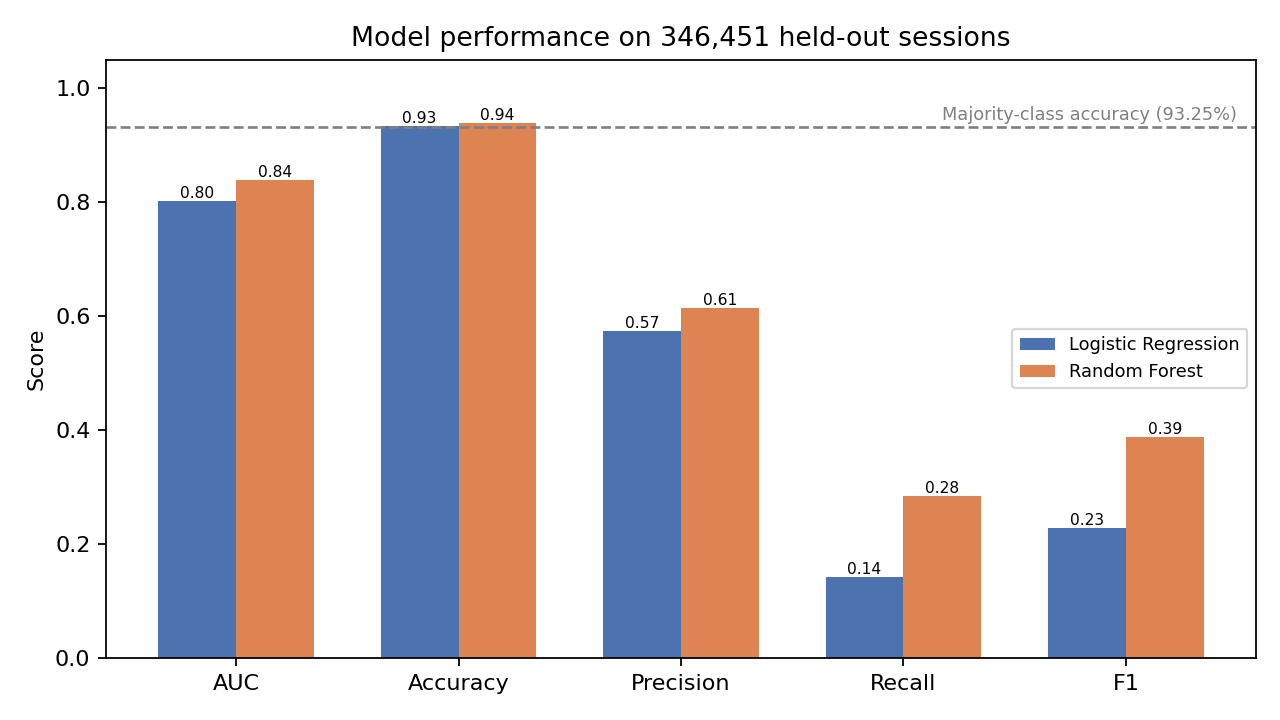

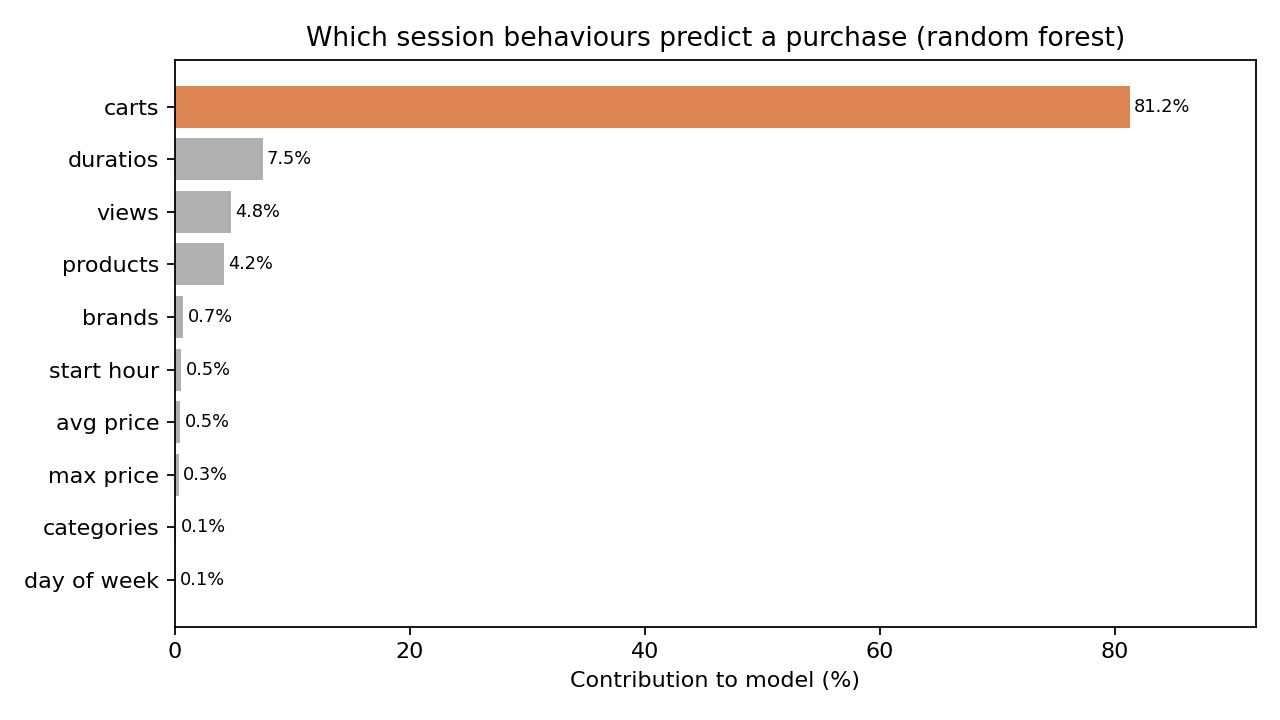

In [21]:
# Cell 32: Two matplotlib charts for Task 4
import json, matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np, os

r = json.load(open('/content/model_results.json'))
OUT = '/content/drive/MyDrive/BDA_Project/evidence'
os.makedirs(OUT, exist_ok=True)

# --- Chart 1: metric comparison, with the majority-class baseline ---
metrics = ['auc','accuracy','precision','recall','f1']
labels  = ['AUC','Accuracy','Precision','Recall','F1']
lr = [r['LogisticRegression'][m] for m in metrics]
rf = [r['RandomForest'][m] for m in metrics]
x = np.arange(len(metrics)); w = 0.35
fig, ax = plt.subplots(figsize=(8,4.5))
b1 = ax.bar(x-w/2, lr, w, label='Logistic Regression', color='#4C72B0')
b2 = ax.bar(x+w/2, rf, w, label='Random Forest', color='#DD8452')
ax.axhline(0.9325, ls='--', lw=1.2, color='grey')
ax.text(len(metrics)-0.5, 0.945, 'Majority-class accuracy (93.25%)', ha='right', fontsize=8, color='grey')
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0,1.05)
ax.set_ylabel('Score'); ax.set_title('Model performance on 346,451 held-out sessions')
ax.legend(fontsize=8); ax.bar_label(b1, fmt='%.2f', fontsize=7); ax.bar_label(b2, fmt='%.2f', fontsize=7)
plt.tight_layout(); plt.savefig(f'{OUT}/fig_model_metrics.png', dpi=160); plt.close()

# --- Chart 2: what drives purchase intent ---
imp = r['RandomForest']['importances']
items = sorted(imp.items(), key=lambda kv: kv[1])
names = [k.replace('n_','').replace('_',' ') for k,_ in items]
vals  = [v*100 for _,v in items]
fig, ax = plt.subplots(figsize=(8,4.5))
bars = ax.barh(names, vals, color=['#DD8452' if v>10 else '#B0B0B0' for v in vals])
ax.set_xlabel('Contribution to model (%)')
ax.set_title('Which session behaviours predict a purchase (random forest)')
ax.bar_label(bars, fmt='%.1f%%', fontsize=8, padding=2); ax.set_xlim(0, 92)
plt.tight_layout(); plt.savefig(f'{OUT}/fig_feature_importance.png', dpi=160); plt.close()

print('Saved to Drive:'); print(os.listdir(OUT))
from IPython.display import Image, display
display(Image(f'{OUT}/fig_model_metrics.png')); display(Image(f'{OUT}/fig_feature_importance.png'))